# DLAG (exact GP) on V1/V2 visual cortex

> **Engine class: dense exact GP** - `ExactEMEngine`, full $T \times T$ Cholesky per EM iter. No SSM, no approximation. Original DLAG implementation.

This notebook re-fits the model from scratch on the V1/V2 dataset, sweeping the
train/val/test partition (`--split-seed`) over `[0, 1, 2]`. The headline
metric is **held-out-neuron co-smoothing PSTH RMSE**: a fraction of neurons
per region is hidden from inference and predicted via the trained $C$ from the
posterior latent inferred on the remaining context neurons. Within each split,
co-smoothing is averaged over 3 different neuron-holdout seeds to reduce
within-split sampling noise.

The diagnostic figures (convergence / delay / latents / PSTH heatmap /
trial-0 / ARD α) are produced from the `split_seed=0` fit as representative
examples. The headline 2-bar figure at the bottom reports the cross-split-seed
mean ± std.


## Configuration

| Knob | Value |
|---|---|
| `n_across`, `n_within` | 2, 2 |
| `init_gamma_across`, `init_gamma_within` | 0.1, 0.1 |
| `ExactEMEngine` `max_lbfgs_iter`, `lbfgs_history` | 40, 15 |
| `num_iters` | 500 |
| Train / val / test split | 300 / 50 / 50 |
| `holdout_frac` | 0.20 |
| `--seed` (model init) | 0 (fixed) |
| `--split-seed` (data partition) | **sweep [0, 1, 2]** |
| `--n-holdout-seeds` | 3 (within-split averaging) |

## Setup

In [1]:
# Bootstrap: add notebooks/ (for nb_helpers if needed) and
# examples/v1v2/ (for v1v2_common) to sys.path.
import sys
from pathlib import Path

_NB_ROOT = Path.cwd()
while _NB_ROOT.name != 'notebooks' and _NB_ROOT.parent != _NB_ROOT:
    _NB_ROOT = _NB_ROOT.parent
sys.path.insert(0, str(_NB_ROOT))
sys.path.insert(0, str(_NB_ROOT.parent / 'examples' / 'v1v2'))

import numpy as np
import torch
import matplotlib.pyplot as plt
import v1v2_common as v1v2
from mbrila import DLAG, ExactEMEngine, LatentSpec, MOSEKernel

DATA_PATH = _NB_ROOT.parent / 'data' / 'demo_v1v2_data.pkl'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE = torch.float64
SPLIT_SEEDS = [0, 1, 2]      # data-partition sweep (headline std)
HOLDOUT_SEEDS = [0, 1, 2]    # neuron-mask sweep, averaged within each split
HOLDOUT_FRAC = 0.20
NUM_TRAIN, NUM_VAL, NUM_TEST = 300, 50, 50
REGION_NAMES = ['V1', 'V2']
ELBO_CHECK_EVERY = 10  # chunked-fit ELBO checkpoint cadence (KalmanEMEngine paths)

print(f'device = {DEVICE}')

device = cuda


## Fit across the 3 split-seeds

Each iteration freshly partitions 400 trials into 300 train / 50 val / 50 test and re-fits. Split 0's model is stashed for the diagnostic figures.

In [2]:
N_ACROSS, N_WITHIN = 2, 2
INIT_GAMMA = 0.1
NUM_ITERS = 500

per_split_results = []
artifacts = None
y_all, y_dims = v1v2.load_v1v2(DATA_PATH, device=DEVICE, dtype=DTYPE)
T = int(y_all.shape[1])
n_regions = len(y_dims)
print(f'data: y={tuple(y_all.shape)}  y_dims={y_dims}')

for split_seed in SPLIT_SEEDS:
    print(f'\n=== split_seed={split_seed} ===')
    torch.manual_seed(0)
    train_data, val_data, test_data = v1v2.make_v1v2_splits(
        y_all, y_dims,
        num_train=NUM_TRAIN, num_val=NUM_VAL, num_test=NUM_TEST,
        split_seed=split_seed,
    )

    spec = LatentSpec(n_across=N_ACROSS, n_within=(N_WITHIN,) * n_regions)
    engine = ExactEMEngine(max_lbfgs_iter=40, lbfgs_history=15, log_every=0)
    model = DLAG(
        latent_spec=spec, y_dims=y_dims, T=T,
        kernel_factory_across=lambda: MOSEKernel(num_regions=n_regions, init_sigma=INIT_GAMMA),
        kernel_factory_within=lambda: MOSEKernel(num_regions=1, init_sigma=INIT_GAMMA),
        engine='exact', engine_override=engine, device=DEVICE, dtype=DTYPE,
    ).to(DEVICE)

    model.initialize_from_data(train_data, mode='pcca')
    result = model.fit(train_data, max_iter=NUM_ITERS, tol=1e-8)
    cosmoothing = v1v2.co_smoothing_eval_multiseed(
        model=model, data=test_data, y_dims=y_dims,
        holdout_frac=HOLDOUT_FRAC, holdout_seeds=HOLDOUT_SEEDS,
    )
    if split_seed == 0:
        artifacts = {
            'fitted_delay': v1v2.extract_delay(model, T),
            'fitted_obs': v1v2.extract_observable(model, train_data),
            'alpha_mean': v1v2.extract_ard_alpha(model),  # None for non-ARD
            'score_iters': np.arange(1, len(result.score_trace) + 1, dtype=float),
            'score_values': np.asarray(result.score_trace, dtype=float) / max(NUM_TRAIN, 1),
            'cosmoothing': cosmoothing,
            'n_across': N_ACROSS,
            'n_within': N_WITHIN,
        }
    per_split_results.append(cosmoothing)
    pm = cosmoothing['per_region_mean']
    print(f'  V1 psth={pm[0][1]:.4f}  V2 psth={pm[1][1]:.4f}')

data: y=(400, 64, 94)  y_dims=(72, 22)

=== split_seed=0 ===


  V1 psth=0.0593  V2 psth=0.0380

=== split_seed=1 ===


  V1 psth=0.0549  V2 psth=0.0451

=== split_seed=2 ===


  V1 psth=0.0591  V2 psth=0.0488


## Aggregate across split-seeds

In [3]:
# Stack per-split co-smoothing results for V1 and V2.
v1_psth_per_split = np.array([r['per_region_mean'][0][1] for r in per_split_results])
v2_psth_per_split = np.array([r['per_region_mean'][1][1] for r in per_split_results])

# Cross-split std = stability of the method across different train/val/test
# partitions of the same 400-trial pool.
v1_mean = float(v1_psth_per_split.mean())
v1_std = float(v1_psth_per_split.std(ddof=1)) if len(v1_psth_per_split) > 1 else 0.0
v2_mean = float(v2_psth_per_split.mean())
v2_std = float(v2_psth_per_split.std(ddof=1)) if len(v2_psth_per_split) > 1 else 0.0

print(f'V1 holdout PSTH RMSE: {v1_mean:.4f} +/- {v1_std:.4f}   (per split: {v1_psth_per_split.tolist()})')
print(f'V2 holdout PSTH RMSE: {v2_mean:.4f} +/- {v2_std:.4f}   (per split: {v2_psth_per_split.tolist()})')

V1 holdout PSTH RMSE: 0.0578 +/- 0.0025   (per split: [0.05934674688919787, 0.05494864441150632, 0.059074461977547725])
V2 holdout PSTH RMSE: 0.0439 +/- 0.0055   (per split: [0.0379641615579568, 0.045050849689816326, 0.04877801773792332])


## Diagnostic figures from split_seed=0

All figures below are produced from the model fit at `split_seed=0`. Other splits give qualitatively similar figures; the cross-split-seed std on the headline bar (later) captures their spread. For mDLAG, ARD-active across-latents are sorted by ascending α (strongest = latent 1).

In [4]:
fitted_delay_plot = artifacts['fitted_delay']
fitted_obs_plot = artifacts['fitted_obs']
N_ACROSS_PLOT = artifacts['n_across']
N_WITHIN_PLOT = artifacts['n_within']
alpha_mean_split0 = artifacts['alpha_mean']
if alpha_mean_split0 is not None and N_ACROSS_PLOT > 0:
    # ARD-active subset (same alpha_prune_ratio=10 as v1v2_common.write_v1v2_outputs).
    max_per_col = alpha_mean_split0.max(axis=0)
    threshold = 10.0 * float(max_per_col.min())
    active_cols = np.flatnonzero(max_per_col <= threshold)
    active_cols = active_cols[np.argsort(max_per_col[active_cols])]
    K_plot = int(active_cols.size)
    if K_plot != N_ACROSS_PLOT or list(active_cols) != list(range(N_ACROSS_PLOT)):
        fitted_delay_plot = artifacts['fitted_delay'][..., active_cols]
        npr_old = N_ACROSS_PLOT + N_WITHIN_PLOT
        npr_new = K_plot + N_WITHIN_PLOT
        n_regions_p = len(artifacts['cosmoothing']['y_true'].shape and (2,))  # always V1+V2 = 2
        B_obs, T_obs = artifacts['fitted_obs'].shape[:2]
        fitted_obs_plot = np.zeros((B_obs, T_obs, 2 * npr_new), dtype=artifacts['fitted_obs'].dtype)
        for r_i in range(2):
            for i, k_src in enumerate(active_cols):
                fitted_obs_plot[..., r_i * npr_new + i] = artifacts['fitted_obs'][..., r_i * npr_old + int(k_src)]
            for w in range(N_WITHIN_PLOT):
                fitted_obs_plot[..., r_i * npr_new + K_plot + w] = artifacts['fitted_obs'][..., r_i * npr_old + N_ACROSS_PLOT + w]
        N_ACROSS_PLOT = K_plot
    print(f'ARD active across-latents kept for plotting: {active_cols.tolist()}')

### Convergence (split_seed=0)

Green `train` line = the engine's per-iter training objective (marginal LL for the dense-GP path, ELBO for mDLAG variants).

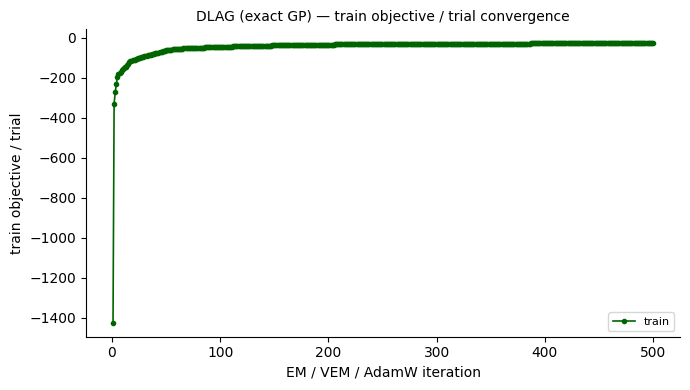

In [5]:
train_trace = np.column_stack([artifacts['score_iters'], artifacts['score_values']])
val_trace = np.zeros((0, 2))  # val LL not computed in notebook
fig = v1v2.plot_convergence(
    train_trace, val_trace, out_path=None,
    model_label="DLAG (exact GP)", ylabel='train objective / trial',
)
plt.show()

### Inter-region delay (V2 - V1) per across-latent

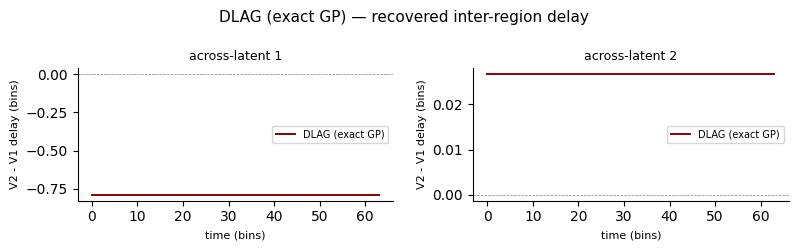

In [6]:
fig = v1v2.plot_delay(fitted_delay_plot, N_ACROSS_PLOT, out_path=None,
                      model_label="DLAG (exact GP)", region_names=REGION_NAMES)
plt.show()

### Per-region smoother latents (trial 0)

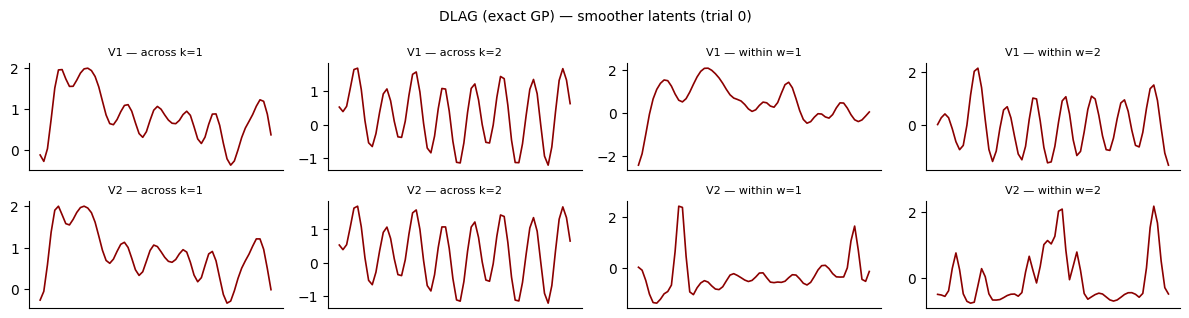

In [7]:
fig = v1v2.plot_latents(fitted_obs_plot, n_regions=2,
                        n_across=N_ACROSS_PLOT, n_within=N_WITHIN_PLOT,
                        out_path=None, model_label="DLAG (exact GP)",
                        region_names=REGION_NAMES, trial=0)
plt.show()

### PSTH matrix: truth | co-smoothing prediction | residual

Held-out neurons sorted to the top of each panel. The reported per-panel RMSE separates held-out (the actual prediction error) vs context (inference error on neurons the model had access to).

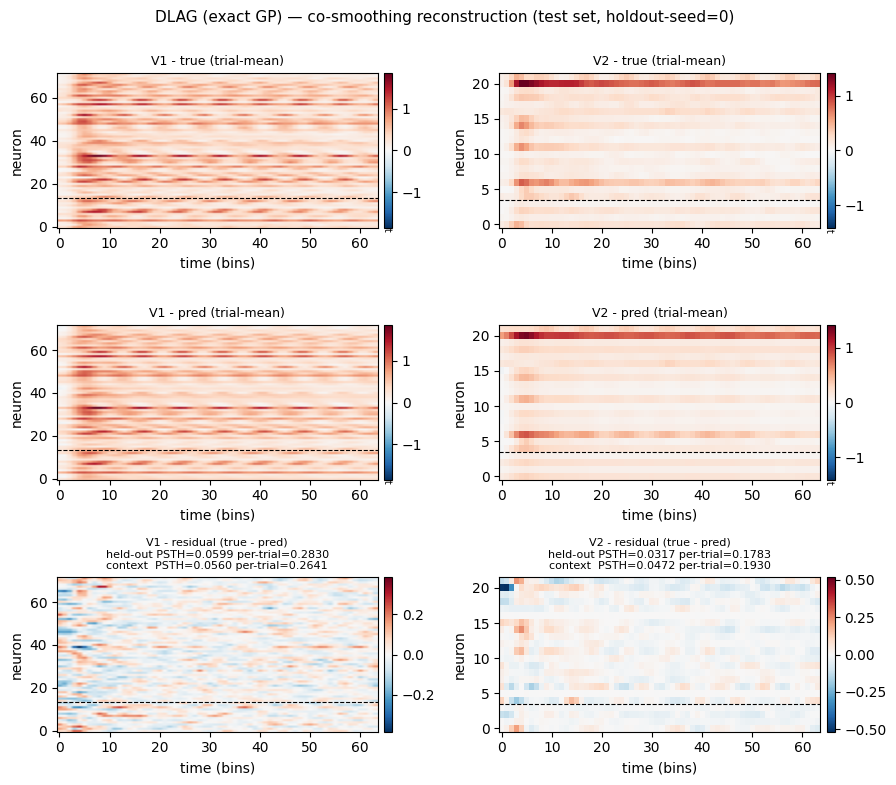

In [8]:
cm = artifacts['cosmoothing']
fig = v1v2.plot_y_recon_psth(
    cm['y_true'], cm['y_recon_plot'], y_dims, out_path=None,
    model_label="DLAG (exact GP)", region_names=REGION_NAMES,
    holdout_indices=cm['holdout_indices_plot'],
    holdout_seed=int(cm['holdout_seeds'][0]),
)
plt.show()

### Single-trial reconstruction (trial 0)

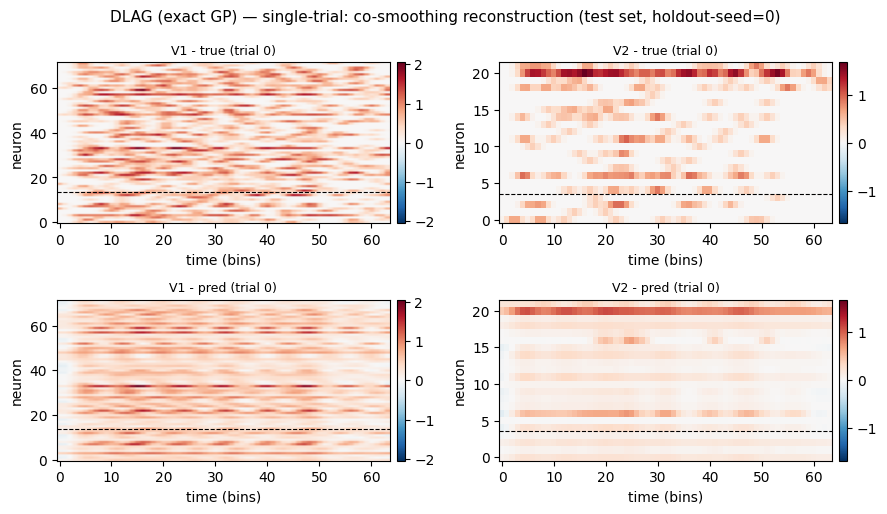

In [9]:
fig = v1v2.plot_y_recon_trial(
    cm['y_true'], cm['y_recon_plot'], y_dims, out_path=None,
    model_label="DLAG (exact GP)", region_names=REGION_NAMES, trial=0,
    holdout_indices=cm['holdout_indices_plot'],
    holdout_seed=int(cm['holdout_seeds'][0]),
)
plt.show()

### ARD α per latent column (mDLAG only)

Bar height = max α over regions per column. Large α = column ARD has pruned. Skipped for non-ARD models (cell will print a note).

In [10]:
if alpha_mean_split0 is not None:
    fig = v1v2.plot_ard_alpha(alpha_mean_split0, out_path=None, model_label="DLAG (exact GP)")
    plt.show()
else:
    print('Non-ARD model - ARD alpha plot skipped.')

Non-ARD model - ARD alpha plot skipped.


## Headline figure: V1 / V2 holdout PSTH RMSE

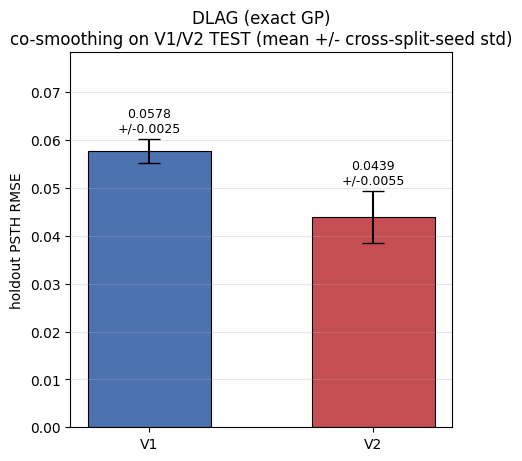

In [11]:
# Headline figure: holdout PSTH RMSE on the TEST split, mean over
# 3 split-seeds, error bars = cross-split-seed std. The std reports
# the method's stability across different data partitions — the
# noise source that varies with the train/val/test shuffle.
fig, ax = plt.subplots(figsize=(4.5, 4.5), constrained_layout=True)
bars = ax.bar(
    ['V1', 'V2'],
    [v1_mean, v2_mean],
    yerr=[v1_std, v2_std],
    color=['#4C72B0', '#C44E52'],
    edgecolor='black',
    linewidth=0.8,
    capsize=8,
    width=0.55,
)
for bar, mu, sd in zip(bars, [v1_mean, v2_mean], [v1_std, v2_std]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + sd + 0.0008,
            f'{mu:.4f}\n+/-{sd:.4f}',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('holdout PSTH RMSE')
ax.set_title("DLAG (exact GP)\nco-smoothing on V1/V2 TEST (mean +/- cross-split-seed std)")
ax.set_ylim(0, max(v1_mean + v1_std, v2_mean + v2_std) * 1.30)
ax.grid(axis='y', alpha=0.3)
plt.show()